In [7]:
import os, sys
os.chdir(r"C:\Users\nurs\OneDrive\Рабочий стол\RiskAware Complaints Engine")
sys.path.insert(0, os.path.abspath("src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from risk_aware.config import load_project_configs
from risk_aware.preprocessing.neural import simple_tokenize

print("cwd:", os.getcwd())
print("src in path:", os.path.abspath("src"))

cwd: C:\Users\nurs\OneDrive\Рабочий стол\RiskAware Complaints Engine
src in path: C:\Users\nurs\OneDrive\Рабочий стол\RiskAware Complaints Engine\src


In [3]:
cfg = load_project_configs("configs")
text_col = cfg["base"]["data"]["text_column"]

train_path = "data/processed/train.csv"
train_df = pd.read_csv(train_path)

print("train shape:", train_df.shape)
print("text column:", text_col)
print("null texts:", train_df[text_col].isna().sum())

train shape: (42611, 6)
text column: consumer_complaint_narrative
null texts: 0


In [4]:
texts = train_df[text_col].astype(str).tolist()
lengths = np.array([len(simple_tokenize(t)) for t in texts], dtype=np.int32)

print("n_texts:", len(lengths))
print("min:", int(lengths.min()), "max:", int(lengths.max()))

n_texts: 42611
min: 2 max: 837


In [5]:
stats = {
    "median": float(np.percentile(lengths, 50)),
    "p90": float(np.percentile(lengths, 90)),
    "p95": float(np.percentile(lengths, 95)),
    "p99": float(np.percentile(lengths, 99)),
    "% > 128": float((lengths > 128).mean() * 100),
    "% > 256": float((lengths > 256).mean() * 100),
    "% > 384": float((lengths > 384).mean() * 100),
}
stats

{'median': 137.0,
 'p90': 434.0,
 'p95': 581.0,
 'p99': 715.0,
 '% > 128': 52.5075684682359,
 '% > 256': 24.83630987303748,
 '% > 384': 12.780737368285184}

In [6]:
report = pd.DataFrame(
    [{"metric": k, "value": v} for k, v in stats.items()]
)
display(report)

out_path = "reports/metrics/neural_token_length_eda_train.csv"
report.to_csv(out_path, index=False)
print("saved:", out_path)

,metric,value
0,median,137.000000
1,p90,434.000000
2,p95,581.000000
3,p99,715.000000
4,% > 128,52.507568
5,% > 256,24.836310
6,% > 384,12.780737


saved: reports/metrics/neural_token_length_eda_train.csv


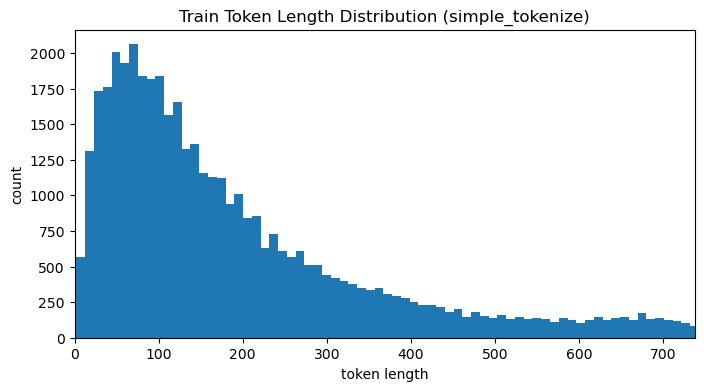

In [8]:
plt.figure(figsize=(8,4))
plt.hist(lengths, bins=80)
plt.title("Train Token Length Distribution (simple_tokenize)")
plt.xlabel("token length")
plt.ylabel("count")
plt.xlim(0, np.percentile(lengths, 99.5))
plt.show()